## 4장 1강: 파이토치 기초 및 심층 신경망

### 6. 파이토치 기반 패션 이미지 다층 모델 실습
#### 6.1 데이터 준비 및 전처리
실습에 필요한 도구 불러오기 및 설정

In [1]:
import platform
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from matplotlib import rc

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"현재 사용 중인 연산 디바이스 : {device}")

# matplotlib 한글 깨짐 방지 설정 
if platform.system() == 'Darwin':      # macOS 환경
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows 환경
    rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

현재 사용 중인 연산 디바이스 : cuda


Fashion MNIST 데이터 불러오기

In [2]:
# Fashion Minist 28 x 28(2차원) (0~255) -> 표준 점수 -> 특성은 1차원으로 변환
# 60,000 -> 훈련 데이터는 50,000장, 검증(10,000)

# 훈련 데이터 셋
raw_train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=ToTensor()
)

# 테스트 데이터 셋
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor()
)

In [3]:
#검증 데이터 셋 분리
train_size = 50000
val_size = 10000

train_data, val_data = random_split(
    raw_train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"데이터 분할 완료 -> 훈련용: {len(train_data)}장 | 검증용: {len(val_data)}장 | 테스트용: {len(test_data)}장")

데이터 분할 완료 -> 훈련용: 50000장 | 검증용: 10000장 | 테스트용: 10000장


In [4]:
# 데이터 세트별 DataLoader 생성
# batch_size -> 에포크에서 전 데이터 셋을 32개의 배치로 분할 -> 미니배치 경사하강법
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)   # 데이터 섞기 활성화 (과적합 방지)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)     # 평가는 섞을 필요 없음
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)   # 평가는 섞을 필요 없음

In [5]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

### 6.2 모델 설계

다층 퍼셉트론(MLP) 모델 클래스 정의

In [6]:
import torch.nn as nn
import torch.optim as optim

class AdvancedFashiorClassifier(nn.Module):

    # 사용할 층(layer)를 정의
    def __init__(self):
        super(AdvancedFashiorClassifier, self).__init__()
        # (28, 28) -> 특성은 1차원으로 변경 (784,)
        self.flatten = nn.Flatten()
        # 입력층(784) -> 은닉층(128) 선형 변환
        self.linear1 = nn.Linear(28 * 28, 128)
        # 활성화 함수로 은닉층에 비선형성 주입을 위한 ReLU 지정
        self.relu = nn.ReLU()
        # 학습 중 뉴런의 20%를 무작위로 비활성화하는 드롭아웃 설정
        self.dropout = nn.Dropout(p=0.2)
        # 은닉층(128) -> 출력층(10) 선형 변환
        self.linear2 = nn.Linear(128, 10)
    
    def __str__(self):
        return f"{super().__str__()}, "

    def __repr__(self):
        return f"{super().__repr__()}, "

    def forward(self, x):
        out = self.flatten(x)
        out = self.linear1(out)
        out = self.relu(out)
        out = self.dropout(out) # 훈련 시에만 적용됨, 과대적합 방지
        out = self.linear2(out) # 별도의 Softmax 없이 Raw 점수(Logits) 출력
        return out

모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당

In [7]:
# 모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당
# 할당된 디바이스 메모리 가중치(Weights)와 편향(Bias) 파라미터가 이동합니다.
model = AdvancedFashiorClassifier().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델의 가속기 이관 완료 | 학습 가능한 총 파라미터 수: {total_params:,}개")

모델의 가속기 이관 완료 | 학습 가능한 총 파라미터 수: 101,770개


손실 함수 및 옵티마이저 정의

In [8]:
# 손실 함수 및 옵티마이저 정의
# nn.CrossEntropyLoss는 내부적으로 Softmax 연산을 포함합니다.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### 6.3 조기 종료 학습 및 검증 루프

In [9]:
epochs = 20 # 최대 에포크
patience = 3 # 검증 로스가 더이상 떨어지지 않는 횟수, 3회 이상이면 학습 종료(조기 종료)
patience_count = 0
best_val_loss = float("inf")

train_losses = []
val_losses = []

print("\n=== 모델 학습 및 검증을 시작합니다. ===")
for epoch in range(epochs):
    # --- [훈련 모드]---
    running_loss = 0
    model.train() # 드롭아웃 등 훈련 전용 기능 활성화

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 이전 그래디언트(기울기)를 초기화

        # 순방향 예측
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 수행 - 그래디언트(기울기)
        loss.backward()

        # 옵티마이저를 통한 가중치 업데이트
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader) # 한 에포크당 평균 로스(배치 로스의 평균)
    train_losses.append(epoch_loss)

    # ---[검증 모드]---
    model.eval() # 드롭아웃 등 평가 시 배제되어야 하는 기능 비활성화(가중치 없데이트)
    val_loss = 0.0

    with torch.no_grad(): # 검증 시에는 미분 계산을 제한하여 연산 자원 최적화
        for images, labels in val_loader:
            # 평가 단계의 미니배치 데이터도 동일하게 가속기로 이관합니다.
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | 훈련 손실: {epoch_loss:.4f} | 검증 손실: {epoch_val_loss:.4f}")

    # --- 조기 종료 조건 검증 로직 ---
    if epoch_val_loss < best_val_loss:
        # 검증 손실이 기존 최적값보다 개선된 경우
        best_val_loss = epoch_val_loss
        patience_count = 0 # 카운터 리셋
        # 최적의 모델 가중치를 파일로 저장
        torch.save(model.state_dict(), "best_fashion_model.pth")
        print(f"=> 최적 모델 저장 완료 (최저 검증 손실 : {best_val_loss:.4f})")
    else:
        # 검증 손실이 개선되지 않은 경우
        patience_count += 1
        print(f"=> 검증 손실 미개선 (조기 종료 대기 카운트 : {patience_count / patience:.4f})")

        # 설정한 참을성(Patience) 한계를 초과하면 학습을 강제 중단
        if patience_count >= patience:
            print(f"\n[Early Stopping 활성화] {epoch+1} 에포크에서 학습을 조기 종료합니다.")
            break

    


=== 모델 학습 및 검증을 시작합니다. ===
Epoch [1/20] | 훈련 손실: 0.6385 | 검증 손실: 0.4868
=> 최적 모델 저장 완료 (최저 검증 손실 : 0.4868)
Epoch [2/20] | 훈련 손실: 0.5612 | 검증 손실: 0.4684
=> 최적 모델 저장 완료 (최저 검증 손실 : 0.4684)
Epoch [3/20] | 훈련 손실: 0.5397 | 검증 손실: 0.4647
=> 최적 모델 저장 완료 (최저 검증 손실 : 0.4647)
Epoch [4/20] | 훈련 손실: 0.5348 | 검증 손실: 0.5177
=> 검증 손실 미개선 (조기 종료 대기 카운트 : 0.3333)
Epoch [5/20] | 훈련 손실: 0.5183 | 검증 손실: 0.4607
=> 최적 모델 저장 완료 (최저 검증 손실 : 0.4607)
Epoch [6/20] | 훈련 손실: 0.5109 | 검증 손실: 0.5165
=> 검증 손실 미개선 (조기 종료 대기 카운트 : 0.3333)
Epoch [7/20] | 훈련 손실: 0.5090 | 검증 손실: 0.4929
=> 검증 손실 미개선 (조기 종료 대기 카운트 : 0.6667)
Epoch [8/20] | 훈련 손실: 0.5124 | 검증 손실: 0.5520
=> 검증 손실 미개선 (조기 종료 대기 카운트 : 1.0000)

[Early Stopping 활성화] 8 에포크에서 학습을 조기 종료합니다.


### 6.4 최종 테스트셋 기반 정확도 측정 및 시각화


=== 최종 테스트셋(실전 성능) 평가 시작 ===
최종 테스트 데이터셋 정확도(Test Accuracy): 82.69%


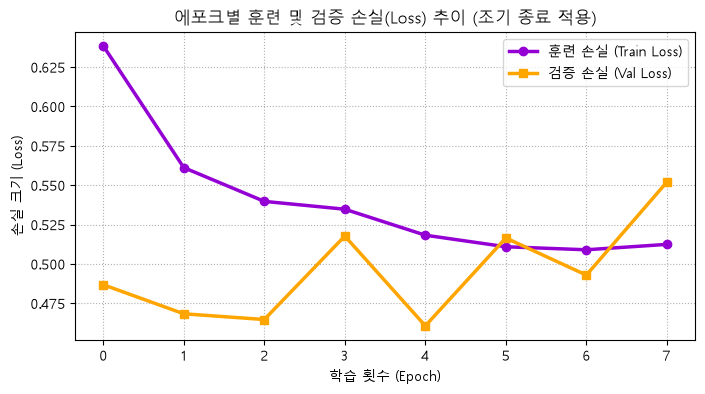

In [10]:
# 학습 과정 중 가장 성적이 좋았던 가중치 파일(pth) 복원
model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)

# 테스트셋 기반 최종 실전 정확도(Accuracy) 측정
model.eval()  # 추론 및 평가 모드로 고정
correct = 0
total = 0

print("\n=== 최종 테스트셋(실전 성능) 평가 시작 ===")
with torch.no_grad():  # 평가 단계이므로 미분 계산 비활성화
    for images, labels in test_loader:
        # 테스트 데이터셋 역시 연산 전 가속기로 이동시킵니다.
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        # 각 행(인스턴스)별로 10개 카테고리 중 가장 높은 점수를 받은 인덱스 추출
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)                       # 전체 데이터 개수 누적
        correct += (predicted == labels).sum().item()  # 정답을 맞춘 개수 누적

test_accuracy = 100 * correct / total
print(f"최종 테스트 데이터셋 정확도(Test Accuracy): {test_accuracy:.2f}%")

# 3. 에포크별 훈련 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()